# **任务15 注意力机制 - (1) | Attention Mechanism (1)**

注意力机制是一种思想，并非某一种固定的结构，我们可以在任何结构中应用它，前提是它确实能提高性能。

本质上只为了让模型在训练过程中自适应输出一个非二值蒙版 **(0.0 ~ 1.0)**，与原输入乘运算以让数据在更重要的特征上更突出，减少后续特征提取的难度。

注意力机制的实际性能需要通过不断实验来创新，所以我就不尝试总结其规律了，只举几个我学习过程中了解到的注意力结构。

## 1. **层记录器类**

只是一个可视化类，并不是深度学习必要的。

In [506]:
import torch
import numpy as np

class NestedLayerGetter:
    """按前向传播顺序记录中间层输出的工具类（支持嵌套Sequential结构）"""
    def __init__(self, model, device='cuda', record_on_train=False, layers_to_record=None):
        self.model = model
        self.device = device
        self.record_on_train = record_on_train  # 训练时是否记录
        self.layers_to_record = layers_to_record  # 指定需要记录的层，None表示所有层
        self.intermediate_outputs = []  # 根层级的输出列表
        self.hooks = []
        self.parent_map = {}  # 记录层与父层的关系
        self.layer_info = {}  # 临时存储层信息，用于构建嵌套结构

        # 首先构建模型的层级结构
        self._build_hierarchy(model)
        # 注册钩子
        self._register_hooks()

    def _build_hierarchy(self, model):
        """构建模型的层级结构，记录每个层的父级"""

        def traverse(parent, module, parent_name=''):
            for name, child in module.named_children():
                current_name = f"{parent_name}.{name}" if parent_name else name
                self.parent_map[current_name] = parent_name
                # 如果是容器类型，继续遍历
                if isinstance(child, (nn.Sequential, nn.ModuleList, nn.ModuleDict)):
                    traverse(current_name, child, current_name)

        traverse('', model)

    def _register_hooks(self):
        """注册钩子，按前向传播顺序记录（支持嵌套结构）"""
        def get_hook(name):
            def hook(module, input, output):
                # 训练模式下且不允许记录时直接返回
                if self.model.training and not self.record_on_train:
                    return

                # 如果指定了需要记录的层且当前层不在其中，则跳过
                if self.layers_to_record is not None and name not in self.layers_to_record:
                    return

                # 处理输入（转为CPU numpy以优化显存）
                processed_input = []
                for inp in input:
                    if isinstance(inp, torch.Tensor):
                        processed_inp = inp.detach().cpu().numpy()  # 切断计算图+转移CPU
                        processed_input.append(processed_inp)
                    else:
                        processed_input.append(inp)

                # 处理输出（转为CPU numpy以优化显存）
                if isinstance(output, torch.Tensor):
                    processed_output = output.detach().cpu().numpy()
                elif isinstance(output, tuple):
                    processed_output = []
                    for out in output:
                        if isinstance(out, torch.Tensor):
                            processed_out = out.detach().cpu().numpy()
                            processed_output.append(processed_out)
                        else:
                            processed_output.append(out)
                    processed_output = tuple(processed_output)
                else:
                    processed_output = output

                # 创建当前层的信息字典
                layer_info = {
                    'name': name.split('.')[-1],  # 只保留最后一级名称
                    'full_name': name,  # 保留完整名称
                    'input': processed_input,
                    'output': processed_output,
                    'module_type': module.__class__.__name__,
                    'children': []  # 用于存储子层
                }

                # 存储层信息
                self.layer_info[name] = layer_info

                # 清理临时变量，减少内存占用
                del processed_input, processed_output

            return hook

        # 为所有子模块注册钩子（按模型结构顺序）
        for name, module in self.model.named_modules():
            if name:  # 跳过根模块（模型本身）
                hook = get_hook(name)
                self.hooks.append(module.register_forward_hook(hook))

    def __call__(self, x):
        """执行前向传播并返回最终输出，每次调用前清空历史记录"""
        self.intermediate_outputs = []
        self.layer_info = {}
        output = self.model(x)

        # 构建嵌套结构
        self._build_nested_structure()
        return output

    def _build_nested_structure(self):
        """根据记录的层信息和父级关系构建嵌套结构"""
        # 首先找出所有顶层节点（没有父节点或父节点未被记录）
        top_level_nodes = []
        for name in self.layer_info:
            parent_name = self.parent_map.get(name, '')
            if parent_name not in self.layer_info:
                top_level_nodes.append(name)

        # 按名称排序，确保顺序正确
        top_level_nodes.sort()

        # 递归构建嵌套结构
        def build_children(parent_name):
            children = []
            # 找出所有以parent_name为前缀的子节点
            for name in self.layer_info:
                if self.parent_map.get(name, '') == parent_name:
                    # 递归构建子节点的子节点
                    self.layer_info[name]['children'] = build_children(name)
                    children.append(self.layer_info[name])
            # 按名称排序
            children.sort(key=lambda x: x['full_name'])
            return children

        # 构建顶层节点的子节点
        for name in top_level_nodes:
            self.layer_info[name]['children'] = build_children(name)
            self.intermediate_outputs.append(self.layer_info[name])

    def clear(self):
        """手动清空记录，释放内存"""
        self.intermediate_outputs = []
        self.layer_info = {}
        import gc
        gc.collect()

    def __del__(self):
        """删除钩子，避免内存泄漏"""
        for hook in self.hooks:
            hook.remove()
        self.clear()

## 2. 视觉注意力

### 2.1 数据生成
以 **任务5** 为例圆形和方形图像的二分类。

输入数据形状: torch.Size([960, 3, 128, 128])
输入批次数量: 8 	批次形状: torch.Size([128, 3, 128, 128])
标签数据形状: torch.Size([960, 4])
输入批次数量: 8 	批次形状: torch.Size([128, 4])


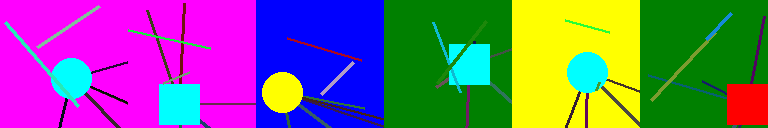

In [507]:
import random
from PIL import Image, ImageDraw
import torchvision.transforms as transforms

def get_data(data_size, img_size, get_all_img=False):
    train_images = []
    # 用于存储对应类别标签的列表
    train_labels = []
    show_img_list = []
    for x in range(data_size // 2):
        col_list = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow']
        b_col = random.choice(col_list)
        col_list.remove(b_col)
        mid_loc = (random.randint(20, img_size-20), random.randint(20, img_size-20))
        r = 20
        loc_0, lod_1 = (mid_loc[0]-r, mid_loc[1]-r), (mid_loc[0]+r, mid_loc[1]+r)
        file_col = random.choice(col_list)

        image0 = Image.new('RGB', (img_size, img_size), b_col)
        draw0 = ImageDraw.Draw(image0)
        for _ in range(5):
            draw0.line([mid_loc, (random.randint(0, 255), random.randint(0, 255))],
                       fill=(random.randint(0, 120), random.randint(0, 120), random.randint(0, 120)), width=3)
        draw0.ellipse((loc_0, lod_1), fill=file_col)
        for _ in range(2):
            draw0.line([(random.randint(0, img_size), random.randint(0, img_size)), (random.randint(20, img_size - 20), random.randint(20, img_size - 20))], fill=(random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)), width=3)

        col_list = ['red', 'green', 'blue', 'cyan', 'magenta', 'yellow']
        b_col = random.choice(col_list)
        col_list.remove(b_col)
        mid_loc = (random.randint(20, img_size-20), random.randint(20, img_size-20))
        r = 20
        loc_0, lod_1 = (mid_loc[0]-r, mid_loc[1]-r), (mid_loc[0]+r, mid_loc[1]+r)
        file_col = random.choice(col_list)

        image1 = Image.new('RGB', (img_size, img_size), b_col)
        draw1 = ImageDraw.Draw(image1)
        for _ in range(5):
            draw1.line([mid_loc, (random.randint(0, 255), random.randint(0, 255))],
                       fill=(random.randint(0, 120), random.randint(0, 120), random.randint(0, 120)), width=3)
        draw1.rectangle((loc_0, lod_1), fill=file_col)
        for _ in range(2):
            draw1.line([(random.randint(0, img_size), random.randint(0, img_size)), (random.randint(20, img_size - 20), random.randint(20, img_size - 20))], fill=(random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)), width=3)

        loc_0, lod_1 = (mid_loc[0] - r - 10, mid_loc[1] - r - 10), (mid_loc[0] + r + 10, mid_loc[1] + r + 10)
        mid_x, mid_y = abs(lod_1[0] + loc_0[0]) / 2 / img_size, abs(lod_1[1] + loc_0[1]) / 2 / img_size
        w_x, h_y = abs(lod_1[0] - loc_0[0]) / img_size, abs(lod_1[1] - loc_0[1]) / img_size

        if len(show_img_list) < 6 or get_all_img:
            show_img_list.append(image0)
            show_img_list.append(image1)

        # 组合变换操作
        transform = transforms.Compose([
            transforms.ToTensor(),
            # 归一化操作，使用上面定义的均值和标准差
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        image0 = transform(image0)
        train_images.append(image0)
        train_labels.append([mid_x, mid_y, w_x, h_y])

        image1 = transform(image1)
        train_images.append(image1)
        train_labels.append([mid_x, mid_y, w_x, h_y])

    # 转换为张量
    train_images, train_labels = torch.stack(train_images), torch.tensor(train_labels)
    return train_images, train_labels, show_img_list

# 划分批次
def split_batch(data, batch_size):
    # 核心操作：沿第一个维度（dim=0）分割，保留后续所有维度
    split_tensors = torch.split(data, batch_size, dim=0)
    # 转为列表返回（torch.split返回tuple，列表更易操作）
    return list(split_tensors)

# 训练数据
img_size = 128
batch_size = 128
train_x, train_y, show_img_list = get_data(960, img_size)
train_x_batch = split_batch(train_x, batch_size)
train_y_batch = split_batch(train_y, batch_size)
# 验证数据
val_x, val_y, _ = get_data(128, img_size)
# 测试数据
test_x, test_y, test_img = get_data(6, img_size, get_all_img=True)
print('输入数据形状:', train_x.shape)
print('输入批次数量:', len(train_x_batch), '\t批次形状:', train_x_batch[0].shape)
print('标签数据形状:', train_y.shape)
print('输入批次数量:', len(train_y_batch), '\t批次形状:', train_y_batch[0].shape)

m = 0
combined = Image.new('RGB', (img_size*len(show_img_list), img_size))
for img in show_img_list:
    combined.paste(img, (m, 0))    # 把a贴到画布左侧
    m += img_size
combined

### 2.2 基于通道的注意力机制

添加 `weight=False` 参数以让该模块拥有纯权重输出和加权后输出的能力，以适应可视化和实际应用。

In [508]:
import math
import torch
import torch.nn as nn

class ECAnet(nn.Module):
    def __init__(self, channel, gamma=2, b=1, weight=False):
        super().__init__()
        self.weight = weight
        kernel_size = int(abs((math.log(channel, 2) + b) / gamma))
        kernel_size = kernel_size if kernel_size % 2 else kernel_size + 1

        # 全局平均池化
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Conv1d(1, 1, kernel_size, bias=False, padding=kernel_size//2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()

        avg = self.avg_pool(x)      # b, c, h, w --> b, c, 1, 1
        avg = avg.view([b, 1, c])      # b, c, h, w --> b, c

        out = self.fc(avg)
        out = self.fc(out).view([b, c, 1, 1])        # b, c --> b, c, 1, 1
        out = self.sigmoid(out)
        if self.weight:
            return out
        else:
            return out * x

#### 2.2.1 定义模型

In [509]:
class MainModelECAnet(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super(MainModelECAnet, self).__init__()
        self.surface_ecanet = ECAnet(input_dim, weight=True)
        self.img_encoder = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(input_dim, hidden_dim, kernel_size=3, padding=1),
            ECAnet(hidden_dim),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            ECAnet(hidden_dim),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            ECAnet(hidden_dim),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            ECAnet(hidden_dim),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.flatten = nn.Flatten()

        self.output_layer = nn.Linear(512, output_dim)

    def forward(self, x):
        x = self.surface_ecanet(x) * x
        x = self.img_encoder(x)
        x = self.flatten(x)
        x = self.output_layer(x)
        return x

#### 2.2.2 模型训练

将模型与层记录器绑定，并指定其记录 `surface_senet` 层的结果。

In [510]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = MainModelECAnet(3, 4, 32).to(device)
recorder = NestedLayerGetter(
        model,
        record_on_train=False,  # 训练时不记录
        layers_to_record=['surface_ecanet']
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

#### **迭代训练**

In [511]:
epochs = 50
for epoch in range(epochs):
    loss = None
    model.train()
    for i in range(len(train_x_batch)):
        x = train_x_batch[i].to(device)
        y = train_y_batch[i].to(device)
        # 前向传播，得到预测值
        # 使用记录器前向传播
        output = recorder(x)
        # 计算损失
        loss = criterion(output, y)
        # 梯度清零，因为在每次反向传播前都要清除之前累积的梯度
        optimizer.zero_grad()
        # 反向传播，计算梯度
        loss.backward()
        # 更新权重和偏置
        optimizer.step()

    val_x = val_x.to(device)
    val_y = val_y.to(device)
    recorder.model.eval()
    output = recorder(val_x)
    val_loss = criterion(output, val_y).item()

    # 更改验证逻辑为适合分类任务的准确率和召回率
    if (epoch + 1) % 10 == 0:
        print(f'[epoch {epoch+1}]loss:', loss.item())
        print(f'\t val loss:', val_loss)


[epoch 10]loss: 0.023107852786779404
	 val loss: 0.022640593349933624
[epoch 20]loss: 0.022643499076366425
	 val loss: 0.021594814956188202
[epoch 30]loss: 0.02080347388982773
	 val loss: 0.020659899339079857
[epoch 40]loss: 0.01847435161471367
	 val loss: 0.01959754340350628
[epoch 50]loss: 0.016018744558095932
	 val loss: 0.018453476950526237


### 2.2.3 **测试模型**

使用 `model.eval()` 将模型改为测试模式，避免自动的梯度计算增加额外的计算量。

前向传播中共记录 1 个顶层步骤：
(6, 3)


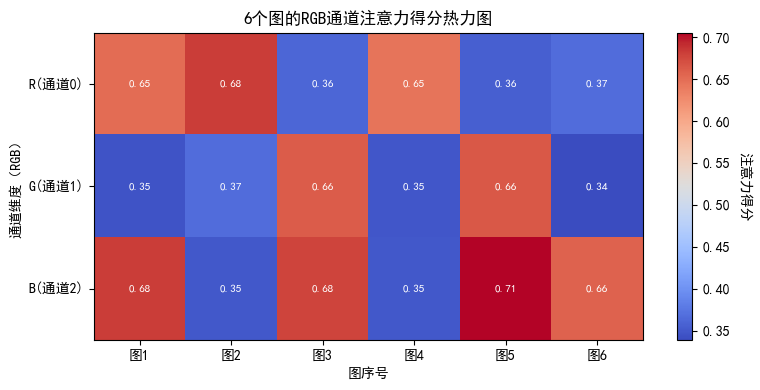

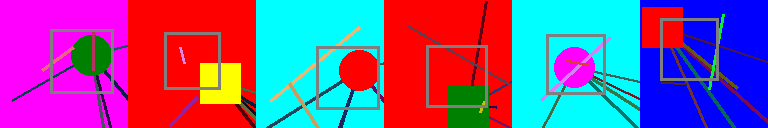

In [512]:
import matplotlib.pyplot as plt

recorder.model.eval()
test_x = test_x.to(device)
# 用记录器前向传播
output = recorder(test_x)



m, i = 0, 0
combined = Image.new('RGB', (img_size*len(test_img), img_size))
for img in test_img:
    draw = ImageDraw.Draw(img)
    mid_x, mid_y, range_w, range_h = output[i].to('cpu').tolist()

    loc_x0 = mid_x * img_size - range_w * img_size / 2
    loc_y0 = mid_y * img_size - range_h * img_size / 2
    loc_x1 = mid_x * img_size + range_w * img_size / 2
    loc_y1 = mid_y * img_size + range_h * img_size / 2

    draw.rectangle(((loc_x0, loc_y0), (loc_x1, loc_y1)), outline=(127, 127, 127), width=3)
    combined.paste(img, (m, 0))    # 把a贴到画布左侧

    m += img_size
    i += 1

recoder_content = recorder.intermediate_outputs
print(f"前向传播中共记录 {len(recoder_content)} 个顶层步骤：")
atte_output_tensor = recoder_content[0]['output']
attn_matrix = torch.tensor(atte_output_tensor).squeeze().numpy()
print(attn_matrix.shape)

plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题
plt.figure(figsize=(8, 4))
im = plt.imshow(attn_matrix.T, cmap='coolwarm', aspect='auto')

x_labels = [f"图{i+1}" for i in range(6)]
y_labels = ['R(通道0)', 'G(通道1)', 'B(通道2)']

plt.xticks(np.arange(6), x_labels)
plt.yticks(np.arange(3), y_labels)

for i in range(3):
    for j in range(6):
        plt.text(j, i, f"{attn_matrix[j, i]:.2f}", ha="center", va="center", color="white", fontsize=8)

cbar = plt.colorbar(im)
cbar.set_label('注意力得分', rotation=270, labelpad=15)

plt.title('6个图的RGB通道注意力得分热力图')
plt.xlabel('图序号')
plt.ylabel('通道维度（RGB）')
plt.tight_layout()
plt.show()

combined

我们可以注意到，对于图像有以下规律。

| 背景颜色 | 注意力高分项 |
|------|--------|
| 红色   | R      |
| 绿色   | G      |
| 红色   | B      |
| 青色   | G, B   |
| 品红   | R, B   |
| 黄色   | R, G   |

该通道注意力机制不止可以用于表层，给RGB三个通道注意力得分，它还可以用于深层，对更多通道进行注意力计算。

## 3. 缩放点积注意力（Q，K，V）

见下一任务。